<a href="https://colab.research.google.com/github/isisjardim/Ciclo-14-Pretalab-Python-Github/blob/main/Aula_10_Pandas_e_Numpy_Avan%C3%A7ado_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando funcionalidades avançadas do Pandas e Numpy

## Objetivos da Aula

- Aprender a **tratar e transformar dados** com Pandas e Numpy.  
- Dominar **operações vetorizadas, máscaras e broadcasting**.  
- Utilizar **métodos avançados** de manipulação: agrupamento, mesclagem e funções personalizadas.  


## 1. Revisão Rápida

Na aula anterior, vimos:

✅ O que são arrays (`ndarray`) e DataFrames.  
✅ Como criar, filtrar e exportar dados.  
✅ Operações básicas de NumPy e Pandas.

Agora, vamos **aprofundar o tratamento e análise de dados** utilizando funcionalidades mais avançadas.


## 2. Recursos Avançados do NumPy

O **NumPy** é excelente para trabalhar com **operações vetorizadas** e **broadcasting**, o que permite cálculos eficientes sem usar laços (`for`).

💡 Essas operações são realizadas elemento a elemento (sem loops explícitos).


### 2.1 Operações Vetorizadas

In [ ]:
import numpy as np

arr1 = np.array([10, 20, 30, 40])
arr2 = np.array([1, 2, 3, 4])

print("Soma:", arr1+arr2)
print("Multiplicação:", arr1*arr2)
print("Divisão:", arr1/arr2)
print("Diferença:", arr1-arr2)

Soma: [11 22 33 44]
Multiplicação: [ 10  40  90 160]
Divisão: [10. 10. 10. 10.]
Diferença: [ 9 18 27 36]


### 2.2 Broadcasting

O broadcasting permite combinar arrays de diferentes tamanhos, desde que suas dimensões sejam compatíveis.

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6], [7,8,9]])
vetor = np.array([10, 20, 30])

print("Array original:\n", arr)
print("\nVetor somado:\n",arr + vetor )

Array original:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Vetor somado:
 [[11 22 33]
 [14 25 36]
 [17 28 39]]


### 2.3 Máscaras Booleanas

Permitem filtrar valores em arrays de forma lógica e vetorizada.

In [ ]:
arr = np.array([10, 15, 20, 25, 30])

masc = arr > 18
print("Máscara:", masc)
print("Valores maiores que 18:", arr[masc])

Máscara: [False False  True  True  True]
Valores maiores que 18: [20 25 30]


### 2.4 Funções Universais (ufuncs)

NumPy fornece várias funções matemáticas otimizadas.

In [ ]:
arr = np.array([[1, 4, 9, 16, 25],
                [36, 49, 64, 81, 100]])

print("Raiz quadrada:", np.sqrt(arr))
print("Quadrado:", np.square(arr))
print("Seno:", np.sin(arr))
print("Logaritmo:", np.log(arr))

Raiz quadrada: [[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]]
Quadrado: [[    1    16    81   256   625]
 [ 1296  2401  4096  6561 10000]]
Seno: [[ 0.84147098 -0.7568025   0.41211849 -0.28790332 -0.13235175]
 [-0.99177885 -0.95375265  0.92002604 -0.62988799 -0.50636564]]
Logaritmo: [[0.         1.38629436 2.19722458 2.77258872 3.21887582]
 [3.58351894 3.8918203  4.15888308 4.39444915 4.60517019]]


### Exercício 1 – Numpy Avançado

1. Crie um array arr com valores de 1 a 12 e reorganize-o em uma matriz 3x4.
Depois:

2. Encontre todos os elementos maiores que a média.

3. Substitua os valores pares por 0.

💡 Use reshape(), mean(), e operações booleanas.

In [ ]:
arr = np.arange(1,13)
matriz = arr.reshape(3, 4)

media = np.mean(matriz)

maiores_que_media = matriz[matriz > media]
matriz[matriz % 2 == 0] = 0
matriz

array([[ 1,  0,  3,  0],
       [ 5,  0,  7,  0],
       [ 9,  0, 11,  0]])

## 3. Funcionalidades Avançadas do Pandas

O Pandas possui métodos poderosos para limpeza, transformação e agregação de dados.
Essas operações são essenciais para preparar dados reais (que muitas vezes vêm “sujos” ou incompletos).

### 3.1 Lidando com Valores Ausentes

In [ ]:
import pandas as pd

dados = {
    'Nome': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Idade': [23, None, 35, None, 29],
    'Nota': [8.5, 7.0, None, 6.5, 9.0]
}

df = pd.DataFrame(dados)
df

,Nome,Idade,Nota
0,Ana,23.0,8.5
1,Bruno,NaN,7.0
2,Carla,35.0,NaN
3,Daniel,NaN,6.5
4,Eva,29.0,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nome    5 non-null      object 
 1   Idade   3 non-null      float64
 2   Nota    4 non-null      float64
dtypes: float64(2), object(1)
memory usage: 252.0+ bytes


In [ ]:
df.describe()

,Idade,Nota
count,3.0,4.000000
mean,29.0,7.750000
std,6.0,1.190238
min,23.0,6.500000
25%,26.0,6.875000
50%,29.0,7.750000
75%,32.0,8.625000
max,35.0,9.000000


In [ ]:
#Verificar valores ausentes
df.isnull().sum()

,0
Nome,0
Idade,2
Nota,1


In [ ]:
#Remover valores ausentes
df_sem_nulos = df.dropna()

In [ ]:
df_sem_nulos

,Nome,Idade,Nota
0,Ana,23.0,8.5
4,Eva,29.0,9.0


In [ ]:
#Preencher valores ausentes
df_preenchido = df.fillna({
    'Idade': df['Idade'].mean(),
    'Nota': df['Idade'].mean()
})

In [ ]:
df_preenchido

,Nome,Idade,Nota
0,Ana,23.0,8.5
1,Bruno,29.0,7.0
2,Carla,35.0,29.0
3,Daniel,29.0,6.5
4,Eva,29.0,9.0


### 3.2 Detectando e Removendo Duplicatas

In [ ]:
df_dup = pd.DataFrame({
    'Produto': ['A', 'B', 'A', 'C', 'B'],
    'Preço': [10, 15, 10, 20, 15]
})

df_dup

,Produto,Preço
0,A,10
1,B,15
2,A,10
3,C,20
4,B,15


In [ ]:
df_dup.drop_duplicates()

,Produto,Preço
0,A,10
1,B,15
3,C,20


### 3.3 Modificando Índices e Colunas

In [ ]:
# Renomeando colunas
df.rename(columns={'Nota': 'Desempenho'}, inplace=True)
df.head()

,Nome,Idade,Desempenho
0,Ana,23.0,8.5
1,Bruno,NaN,7.0
2,Carla,35.0,NaN
3,Daniel,NaN,6.5
4,Eva,29.0,9.0


In [ ]:
# Redefinindo o índice
df.set_index('Nome', inplace=True)
df.reset_index()

,Nome,Idade,Desempenho
0,Ana,23.0,8.5
1,Bruno,NaN,7.0
2,Carla,35.0,NaN
3,Daniel,NaN,6.5
4,Eva,29.0,9.0


### 3.4 Ordenando Dados

In [ ]:
df_preenchido.sort_values(by='Nota', ascending=False)

,Nome,Idade,Nota
2,Carla,35.0,29.0
4,Eva,29.0,9.0
0,Ana,23.0,8.5
1,Bruno,29.0,7.0
3,Daniel,29.0,6.5


### 3.5 Agrupamento de Dados (groupby)

💡 `groupby()` permite calcular médias, somas e outras estatísticas por grupos.

In [ ]:
dados = {
    'Categoria': ['A', 'A', 'B', 'B', 'C', 'C'],
    'Valor': [10, 15, 10, 25, 20, 30]
}

df = pd.DataFrame(dados)
df

,Categoria,Valor
0,A,10
1,A,15
2,B,10
3,B,25
4,C,20
5,C,30


In [ ]:
#Agregação Simples
df.groupby('Categoria')['Valor'].sum()

# SELECT SUM(valor)
# FROM df
# GROUP BY Categoria

,Valor
Categoria,
A,25
B,35
C,50


In [ ]:
#Agregações Múltiplas
df.groupby('Categoria').agg({
    'Valor':['mean','sum', 'max', 'min']
})

Valor            
           mean sum max min
Categoria                  
A          12.5  25  15  10
B          17.5  35  25  10
C          25.0  50  30  20

### Exercício 2 – Pandas: Tratamento de Dados

1. Crie o DataFrame a seguir:

```
df = pd.DataFrame({
    'Cidade': ['São Paulo', 'Rio', 'BH', 'São Paulo', None],
    'Vendas': [1000, None, 800, 1200, 900],
    'Ano': [2023, 2023, 2024, 2024, 2024]
})
```

2. Substitua valores ausentes de “Vendas” pela média.

3. Preencha o campo “Cidade” ausente com “Desconhecida”.

4. Calcule o total de vendas por cidade e ano.

5. Ordene o resultado do maior para o menor total.

In [ ]:
df_vendas = pd.DataFrame({
    'Cidade': ['São Paulo', 'Rio', 'BH', 'São Paulo', None],
    'Vendas': [1000, None, 800, 1200, 900],
    'Ano': [2023, 2023, 2024, 2024, 2024]
})

In [ ]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cidade  4 non-null      object 
 1   Vendas  4 non-null      float64
 2   Ano     5 non-null      int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 252.0+ bytes


In [ ]:
df_vendas['Vendas']

,Vendas
0,1000.0
1,NaN
2,800.0
3,1200.0
4,900.0


In [ ]:
#Substitua valores ausentes de “Vendas” pela média.
df_vendas['Vendas'].fillna(df_vendas['Vendas'].mean(), inplace=True)

In [ ]:
df_vendas['Cidade']

,Cidade
0,São Paulo
1,Rio
2,BH
3,São Paulo
4,None


In [ ]:
#Preencha o campo “Cidade” ausente com “Desconhecida”.
df_vendas['Cidade'].fillna('Desconhecida', inplace=True)

In [ ]:
df_vendas

,Cidade,Vendas,Ano
0,São Paulo,1000.0,2023
1,Rio,975.0,2023
2,BH,800.0,2024
3,São Paulo,1200.0,2024
4,Desconhecida,900.0,2024


In [ ]:
#Calcule o total de vendas por cidade e ano
#Ordene o resultado do maior para o menor total
df_vendas.groupby(['Cidade','Ano'])['Vendas'].sum().sort_values(ascending=False)

Cidade        Ano 
São Paulo     2024    1200.0
              2023    1000.0
Rio           2023     975.0
Desconhecida  2024     900.0
BH            2024     800.0
Name: Vendas, dtype: float64

### 3.6 Mesclagem e Junção de DataFrames

Semelhante a “joins” de SQL.

In [ ]:
clientes = pd.DataFrame({
    'id_cliente': [1, 2, 3],
    'nome': ['Ana', 'Bruno', 'Carla']
})

compras = pd.DataFrame({
    'id_cliente': [1, 2, 1, 3],
    'valor': [100, 250, 300, 150]
})

In [ ]:
clientes

,id_cliente,nome
0,1,Ana
1,2,Bruno
2,3,Carla


In [ ]:
compras

,id_cliente,valor
0,1,100
1,2,250
2,1,300
3,3,150


In [ ]:
pd.merge(clientes, compras, on='id_cliente')

,id_cliente,nome,valor
0,1,Ana,100
1,1,Ana,300
2,2,Bruno,250
3,3,Carla,150


### 3.7 Aplicação de Funções com apply() e lambda

Permite criar transformações personalizadas nas colunas.

In [ ]:
df = pd.DataFrame({
    'Nome': ['Ana', 'Bruno', 'Carla'],
    'Nota': [8.5, 7.2, 9.0]
})

In [ ]:
df['Conceito'] = df['Nota'].apply(lambda x: 'A' if x>=9 else ('B' if x >= 7 else 'C'))

In [ ]:
df['Dobro_Nota'] = df['Nota'].apply(lambda x: 2*x)

In [ ]:
df

,Nome,Nota,Conceito,Dobro_Nota
0,Ana,8.5,B,17.0
1,Bruno,7.2,B,14.4
2,Carla,9.0,A,18.0


### Exercício 3 – Pandas: Aplicação de Funções e Agrupamentos

Utilizando o dataset abaixo:

```
dados = {
    'Funcionário': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eduarda'],
    'Departamento': ['Vendas', 'Vendas', 'TI', 'TI', 'RH'],
    'Salário': [4000, 4500, 5000, 5500, 4200]
}

df = pd.DataFrame(dados)
```

1. Aumente o salário de todos os funcionários de TI em 10%.

2. Crie uma coluna “Faixa Salarial” (≥ 5000 → “Alta”, senão “Média”).

3. Agrupe os dados por “Departamento” e calcule a média salarial.

In [ ]:
dados = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eduarda'],
    'Departamento': ['Vendas', 'Vendas', 'TI', 'TI', 'RH'],
    'Salario': [4000, 4500, 5000, 5500, 4200]
}

df = pd.DataFrame(dados)

In [ ]:
df

,Funcionario,Departamento,Salario
0,Ana,Vendas,4000
1,Bruno,Vendas,4500
2,Carla,TI,5000
3,Daniel,TI,5500
4,Eduarda,RH,4200


In [ ]:
#Aumente o salário de todos os funcionários de TI em 10%
df.loc[df['Departamento'] == 'TI','Salario'] *= 1.10

/tmp/ipython-input-1321238442.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5500. 6050.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Departamento'] == 'TI','Salario'] *= 1.10


In [ ]:
df

,Funcionario,Departamento,Salario
0,Ana,Vendas,4000.0
1,Bruno,Vendas,4500.0
2,Carla,TI,5500.0
3,Daniel,TI,6050.0
4,Eduarda,RH,4200.0


In [ ]:
#Crie uma coluna “Faixa Salarial” (≥ 5000 → “Alta”, senão “Média”)
df['Faixa_Salarial'] = df['Salario'].apply(lambda x: 'Alta' if x>=5000 else 'Media')

In [ ]:
df

,Funcionario,Departamento,Salario,Faixa_Salarial
0,Ana,Vendas,4000.0,Media
1,Bruno,Vendas,4500.0,Media
2,Carla,TI,5500.0,Alta
3,Daniel,TI,6050.0,Alta
4,Eduarda,RH,4200.0,Media


In [ ]:
#Agrupe os dados por “Departamento” e calcule a média salarial
df_media_salarial = df.groupby('Departamento')['Salario'].mean().reset_index()

In [ ]:
df_media_salarial

,Departamento,Salario
0,RH,4200.0
1,TI,5775.0
2,Vendas,4250.0


### 3.8 Visualização de Dados com Pandas

In [ ]:
import matplotlib.pyplot as plt

dados = {
    'Mês': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'],
    'Vendas': [12000, 15000, 10000, 18000, 22000, 20000],
    'Lucro': [3000, 4000, 2000, 5000, 7000, 6500]
}

df = pd.DataFrame(dados)

<Axes: title={'center': 'Vendas por mês'}, xlabel='Mês'>

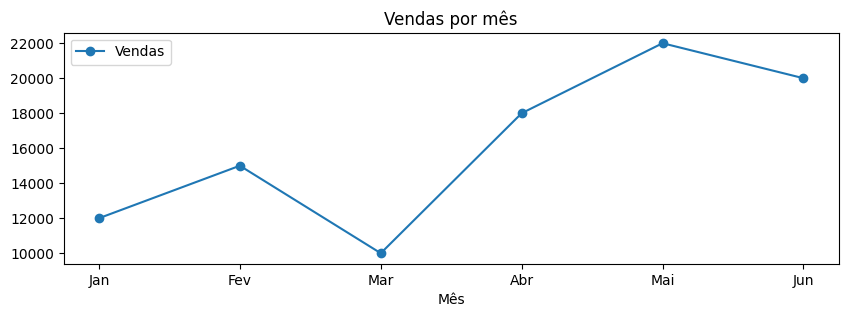

In [ ]:
#Gráfico de Linhas
df.plot(x='Mês', y='Vendas', kind='line', marker='o', title='Vendas por mês', figsize=(10,3))

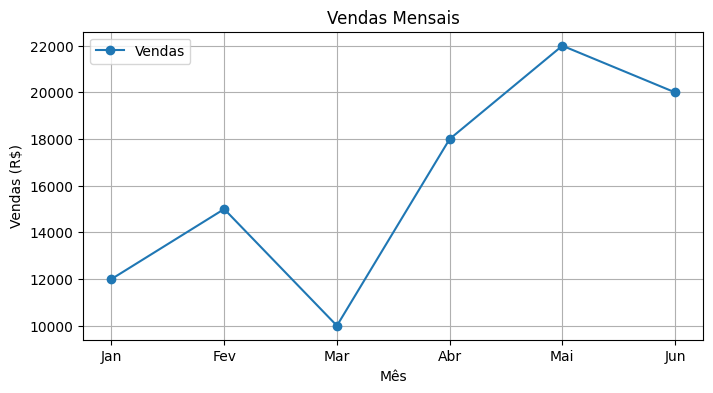

In [ ]:
df.plot(x='Mês', y='Vendas', kind='line', marker='o', title='Vendas Mensais', figsize=(8,4))
plt.ylabel('Vendas (R$)')
plt.xlabel('Mês')
plt.grid(True)

O gráfico de linhas é ideal para visualizar tendências ao longo do tempo.

💡 Dica: o parâmetro kind='line' é o padrão em df.plot().

<Axes: title={'center': 'Lucro Mensal'}, xlabel='Mês'>

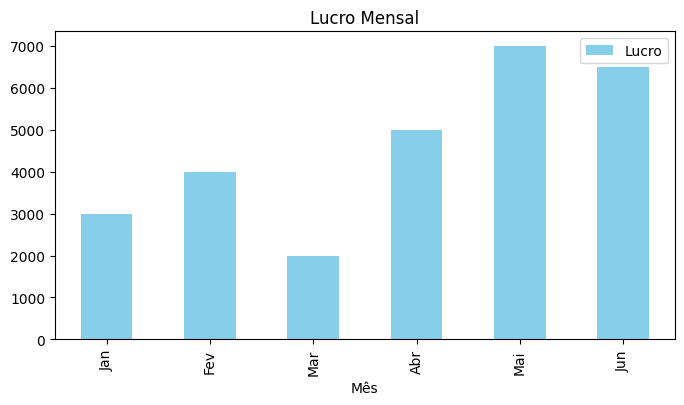

In [ ]:
#Gráfico de Barras
df.plot(x='Mês', y='Lucro', kind='bar', color='skyblue', title='Lucro Mensal', figsize=(8,4))

O gráfico de barras é útil para comparar categorias ou períodos distintos.

💡 Você pode usar kind='barh' para criar barras horizontais.

Para comparar várias métricas lado a lado:

<Axes: xlabel='Mês'>

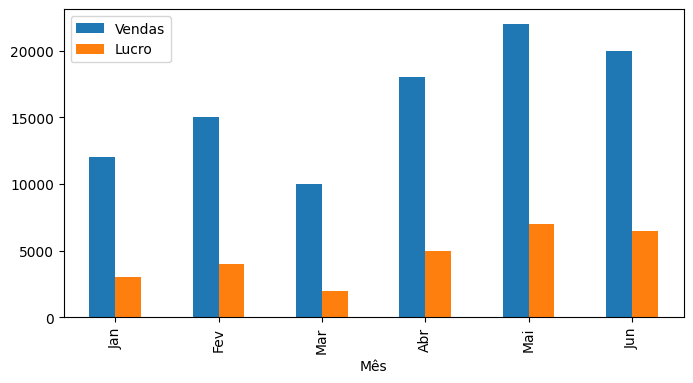

In [ ]:
#Gráfico de Barras Múltiplas
df.plot(x='Mês', y=['Vendas', 'Lucro'], kind='bar', figsize=(8,4))

<Axes: title={'center': 'Vendas por mês'}, xlabel='Vendas', ylabel='Lucro'>

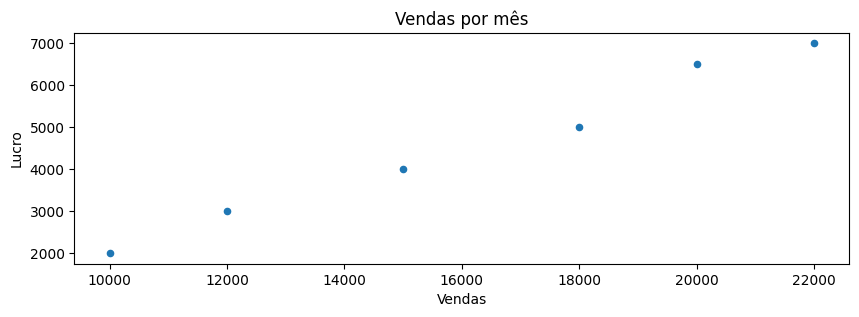

In [ ]:
#Gráfico de Dispersão
df.plot(x='Vendas', y='Lucro', kind='scatter', title='Vendas por mês', figsize=(10,3))

Útil para visualizar relações entre duas variáveis (ex: Vendas × Lucro).

In [ ]:
#Gráfico a partir de Dados Agrupados

# Dataset de exemplo
vendas = pd.DataFrame({
    'Região': np.random.choice(['Sul', 'Sudeste', 'Nordeste', 'Centro-Oeste'], 50),
    'Valor': np.random.randint(1000, 10000, 50)
})

# Agrupar por região
vendas_agrupadas = vendas.groupby('Região')['Valor'].sum().sort_values(ascending=False)

In [ ]:
vendas

,Região,Valor
0,Sudeste,4459
1,Sudeste,3307
2,Centro-Oeste,6527
3,Sudeste,9081
4,Centro-Oeste,1920
5,Sudeste,1702
6,Sul,7800
7,Nordeste,2644
8,Nordeste,8376
9,Nordeste,5099


In [ ]:
vendas_agrupadas

,Valor
Região,
Sul,73583
Nordeste,72880
Centro-Oeste,60001
Sudeste,52051


<Axes: xlabel='Região'>

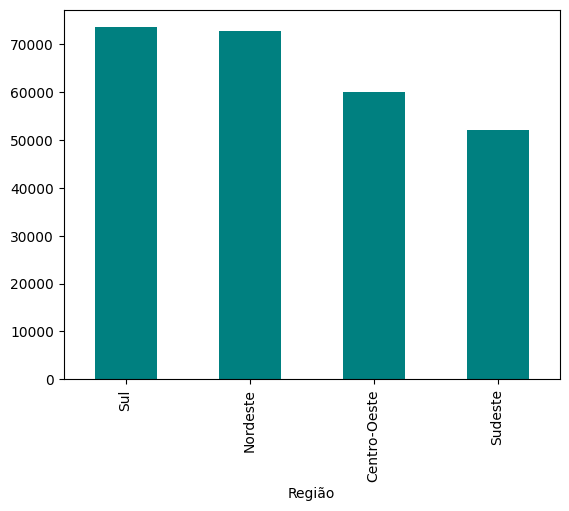

In [ ]:
# Plotar gráfico de barras
vendas_agrupadas.plot(kind='bar', color='teal')

### Exercício 4

1. Crie um novo DataFrame com as colunas:

| Região       | Total_Vendas |
| ------------ | ------------ |
| Sul          | 18000        |
| Sudeste      | 25000        |
| Nordeste     | 12000        |
| Centro-Oeste | 9000         |


2. Faça um gráfico de barras mostrando o total por região.

##Resumo da Aula

Nesta aula, você aprendeu:

* NumPy: broadcasting, máscaras e funções matemáticas avançadas.

* Pandas: limpeza de dados, agregações, agrupamentos e funções personalizadas.

### Próxima Aula

➡️ Prática de manipulação de datasets com Pandas.